# High-Dimensional Latent Geodesics

Interpolating between two codes in the latent space of a generative model is a
geodesic problem. A straight line cuts through the low-density region between data
clusters and decodes to blurry, off-distribution samples; a geodesic under a
*data-aware* metric stays where the data lives and decodes to valid samples.
Following the energy-based-model geometry of
[Syrota et al. (2025)](https://arxiv.org/abs/2505.18230), we equip the latent with a
conformal Riemannian metric derived from a kernel-density EBM and solve the geodesic
**boundary-value problem (BVP)** with HAM's `AVBDSolver` and `GaussNewtonGeodesic` —
for any Finsler metric, with no per-pair training.

The notebook is in two parts. Sections 1–5 demonstrate a working high-dimensional
example: a clean latent-space rotation of a learned character, recovered by pairing
a global initialiser with a local geometric refiner. Sections 6–8 then study, with
controlled experiments, when and why the boundary-value problem is hard, and state
the limitations and challenges that remain.

**Metric-first design.** A HAM `FinslerMetric` is specified by a single scalar field,
the Finsler cost $F(x, v)$, which defines the path energy
$$\mathcal{E}[\gamma] = \int \tfrac{1}{2}\, F^2(x, \dot{x})\, dt.$$
The geodesic spray, fundamental tensor, curvature, and Berwald parallel transport are
then obtained by automatic differentiation of $F$ with `jax.grad` / `jax.hessian`,
rather than by hand-deriving Christoffel symbols. The notebooks in this suite share a
small plotting style (`ham.vis.style`) so the figures stay consistent and readable.

In [1]:
import time
import numpy as np
import jax
import jax.numpy as jnp
import equinox as eqx
import optax
import matplotlib.pyplot as plt

from ham.geometry import EuclideanSpace, Riemannian, SegmentQuadratureMetric
from ham.nn.kde import GaussianKDEEnergy
from ham.solvers import (
    AVBDSolver, GaussNewtonGeodesic, solve_continuation,
    geodesic_graph_init, build_knn_graph, reparametrize_arclength,
)
from ham.vis.style import use_ham_style, PALETTE

use_ham_style()
jax.config.update("jax_enable_x64", False)
np.random.seed(0)
IMG = 32
PIX = IMG * IMG
LAT = 24
print("ambient pixel dim =", PIX, "| latent dim =", LAT)

ambient pixel dim = 1024 | latent dim = 24


## 1. A learned latent space of rotated characters

We render a clearly oriented letter **"F"** (no rotational or reflective symmetry, so
its orientation is unambiguous) at 120 rotation angles, with **within-class jitter** —
small random scale, translation and stroke width. The data therefore forms a *thick
tube* rather than a razor-thin curve; this variation is characteristic of real
generative latents and gives the geodesic room to resolve (Section 6 shows that a
razor-thin loop is substantially harder). A small MLP autoencoder
$\mathbb{R}^{1024}\!\to\!\mathbb{R}^{24}\!\to\!\mathbb{R}^{1024}$ learns the latent.

In [2]:
def _stroke(fx, fy, p0, p1, w):
    # Gaussian-profile thick line segment p0->p1 rasterised on a grid.
    ax, ay = p0; bx, by = p1
    vx, vy = bx - ax, by - ay
    L2 = vx * vx + vy * vy + 1e-9
    t = np.clip(((fx - ax) * vx + (fy - ay) * vy) / L2, 0, 1)
    d2 = (fx - (ax + t * vx)) ** 2 + (fy - (ay + t * vy)) ** 2
    return np.exp(-d2 / (2 * w * w))


def render_letter(angle, jitter=None):
    # A rotated 'F' about the image centre; optional small jitter.
    yy, xx = np.mgrid[0:IMG, 0:IMG].astype(np.float32)
    c = (IMG - 1) / 2
    sc, dx, dy, w = 1.0, 0.0, 0.0, 1.3
    if jitter is not None:
        sc = 1.0 + jitter.get("s", 0.0); dx = jitter.get("dx", 0.0)
        dy = jitter.get("dy", 0.0); w = 1.3 + jitter.get("w", 0.0)
    x, y = (xx - c - dx), (yy - c - dy)
    ca, sa = np.cos(-angle), np.sin(-angle)
    xr, yr = (ca * x - sa * y) / sc, (sa * x + ca * y) / sc
    spine = _stroke(xr, yr, (-3, -7), (-3, 7), w)
    top = _stroke(xr, yr, (-3, 7), (5, 7), w)
    mid = _stroke(xr, yr, (-3, 1), (3, 1), w)
    return np.clip(spine + top + mid, 0, 1).astype(np.float32)


N_ANG, M_PER = 120, 8
angles = np.linspace(0, 2 * np.pi, N_ANG, endpoint=False)
_rng = np.random.RandomState(0)
imgs, ang_label = [], []
for a in angles:
    for _ in range(M_PER):
        j = dict(s=_rng.uniform(-.08, .08), dx=_rng.uniform(-1.2, 1.2),
                 dy=_rng.uniform(-1.2, 1.2), w=_rng.uniform(-.15, .25))
        imgs.append(render_letter(a, j).ravel()); ang_label.append(a)
X = jnp.asarray(np.stack(imgs)); ang_label = np.array(ang_label)
print("data:", X.shape, f"| {N_ANG} angles x {M_PER} jittered samples (a thick tube)")


class AE(eqx.Module):
    enc: eqx.nn.MLP
    dec: eqx.nn.MLP

    def __init__(self, key):
        ke, kd = jax.random.split(key)
        self.enc = eqx.nn.MLP(PIX, LAT, 256, 2, activation=jax.nn.silu, key=ke)
        self.dec = eqx.nn.MLP(LAT, PIX, 256, 2, activation=jax.nn.silu,
                              final_activation=jax.nn.sigmoid, key=kd)

    def encode(self, x): return self.enc(x)
    def decode(self, z): return self.dec(z)


model = AE(jax.random.PRNGKey(0))
opt = optax.adam(2e-3)
opt_state = opt.init(eqx.filter(model, eqx.is_array))


@eqx.filter_jit
def train_step(model, opt_state, xb):
    def loss_fn(m):
        return jnp.mean((jax.vmap(m.decode)(jax.vmap(m.encode)(xb)) - xb) ** 2)
    loss, grads = eqx.filter_value_and_grad(loss_fn)(model)
    updates, opt_state = opt.update(grads, opt_state, model)
    return eqx.apply_updates(model, updates), opt_state, loss


t0 = time.time(); key = jax.random.PRNGKey(1)
for step in range(3500):
    key, sk = jax.random.split(key)
    idx = jax.random.choice(sk, X.shape[0], (128,), replace=False)
    model, opt_state, loss = train_step(model, opt_state, X[idx])
print(f"trained in {time.time()-t0:.1f}s | final reconstruction MSE {float(loss):.5f}")

data: (960, 1024) | 120 angles x 8 jittered samples (a thick tube)


trained in 16.2s | final reconstruction MSE 0.00023


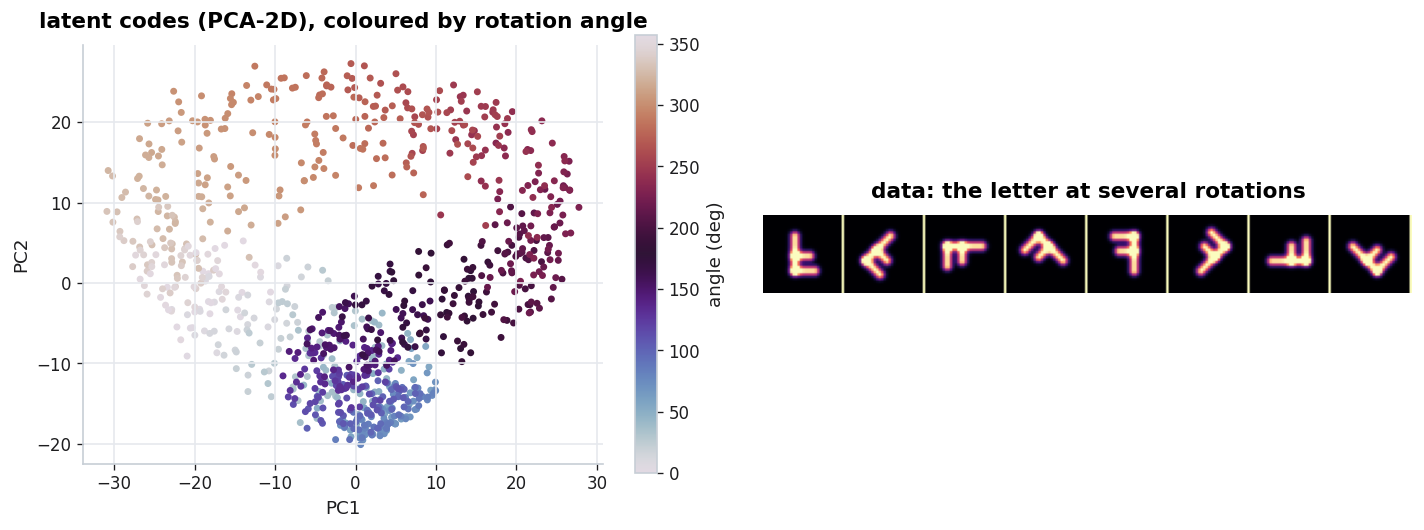

the rotation orbit is a consolidated loop; 2-D PCA captures 45%


In [3]:
Z = np.array(jax.vmap(model.encode)(X))


def decode_img(z):
    return np.array(model.decode(jnp.asarray(z))).reshape(IMG, IMG)


def latent_of_angle(a):  # a clean (un-jittered) endpoint
    return jnp.asarray(model.encode(jnp.asarray(render_letter(a).ravel())))


# PCA to 2-D for visualisation only (metric/solver use all 32 dims).
Zc = Z - Z.mean(0)
U, S, Vt = np.linalg.svd(Zc, full_matrices=False)
Z2 = Zc @ Vt[:2].T

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
sc = ax[0].scatter(Z2[:, 0], Z2[:, 1], c=np.degrees(ang_label), cmap="twilight", s=10)
ax[0].set_title("latent codes (PCA-2D), coloured by rotation angle")
ax[0].set_xlabel("PC1"); ax[0].set_ylabel("PC2"); ax[0].set_aspect("equal")
plt.colorbar(sc, ax=ax[0], label="angle (deg)")
ax[1].axis("off")
strip = np.concatenate([np.concatenate([render_letter(a), np.ones((IMG, 1))], 1)
                        for a in angles[::15]], axis=1)
ax[1].imshow(strip, cmap="magma"); ax[1].set_title("data: the letter at several rotations")
plt.tight_layout(); plt.show()
print(f"the rotation orbit is a consolidated loop; 2-D PCA captures {S[:2].sum()/S.sum():.0%}")

## 2. Linear interpolation leaves the manifold

Averaging two latent codes for rotations $0^\circ$ and $\theta^\circ$ traverses the
*chord* of the latent loop, which passes through its empty interior. Decoding the
midpoints gives a faded **double-exposure** letter — a sample that never occurs.

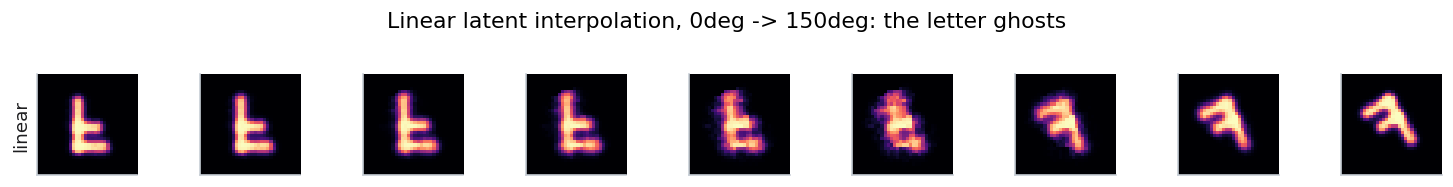

In [4]:
def show_strip(paths, labels, title, k=9):
    rows = len(paths)
    fig, axes = plt.subplots(rows, k, figsize=(1.4 * k, 1.5 * rows))
    axes = np.atleast_2d(axes)
    for r, P in enumerate(paths):
        idx = np.linspace(0, len(P) - 1, k).astype(int)
        for c, t in enumerate(idx):
            axes[r, c].imshow(decode_img(P[t]), cmap="magma", vmin=0, vmax=1)
            axes[r, c].set_xticks([]); axes[r, c].set_yticks([])
        axes[r, 0].set_ylabel(labels[r], fontsize=11)
    fig.suptitle(title, y=1.02); plt.tight_layout(); plt.show()


THETA = np.deg2rad(150)
z0, z1 = latent_of_angle(0.0), latent_of_angle(THETA)
n_steps = 28
linear = np.linspace(np.array(z0), np.array(z1), n_steps + 1)
show_strip([linear], ["linear"],
           "Linear latent interpolation, 0deg -> 150deg: the letter ghosts")

## 3. A data-aware (energy-based) metric, properly calibrated

We place a conformal Riemannian metric on the latent whose factor is driven by the
**energy of a kernel-density EBM** of the data — cheap where data is dense,
expensive in the void ($G_{E_\theta}$ of
[Syrota et al. (2025)](https://arxiv.org/abs/2505.18230)):
$$ G(z)=\exp\!\big(\mathrm{clip}(\alpha[E(z)-E_0],\,-c_0,\,\log c)\big)\,I,\qquad E(z)=-\log\hat p(z).$$
The factor is **small on the dense data ridge** (pulling the path onto the
manifold) and **capped at $c\!=\!10^3\,I$ in the void** — the cap is the
stabilising calibration: an uncalibrated $\exp(\alpha(E-E_0))$ explodes past
$10^{17}\times$, destabilising every solver for no benefit.

We also wrap the metric in `SegmentQuadratureMetric`, which scores each path
segment by a **midpoint** sample of the metric rather than its start vertex. This
matches the midpoint rule in `FinslerMetric.arc_length` and prevents a segment from
*tunnelling* cheaply across a void it never samples (§6).

In [5]:
seg = float(np.median(np.linalg.norm(np.diff(Z, axis=0), axis=1)))
# bandwidth: median distance to the 5th latent neighbour (robust on a tube)
sub = range(0, len(Z), 23)
sigma = float(np.median([np.partition(np.linalg.norm(Z - Z[i], axis=1), 5)[5] for i in sub]))
kde = GaussianKDEEnergy(centers=jnp.asarray(Z), sigma=sigma)
E0 = float(jnp.mean(jax.vmap(kde)(jnp.asarray(Z))))
CAP = 1e3


ALPHA = 6.0  # conformal exponent for the (stiff) solve


def make_metric(alpha, nquad=2, cap=CAP):
    logcap = float(np.log(cap))
    def g_net(z):
        e = jnp.clip(alpha * (kde(z) - E0), -20.0, logcap)
        return jnp.exp(e) * jnp.eye(LAT)
    return SegmentQuadratureMetric(Riemannian(EuclideanSpace(LAT), g_net), nquad=nquad)


mid = 0.5 * (z0 + z1)
raw_factor = np.exp(ALPHA * (float(kde(mid)) - E0))
print(f"KDE bandwidth sigma = {sigma:.3f}")
print(f"conformal factor at the straight-line midpoint: raw exp would be {raw_factor:.1e} x, "
      f"capped at {min(raw_factor, CAP):.1e} x")

KDE bandwidth sigma = 5.836
conformal factor at the straight-line midpoint: raw exp would be 5.1e+04 x, capped at 1.0e+03 x


## 4. Globalising the geodesic: eikonal initialisation and local refinement

A geodesic BVP is **globally non-convex**: a straight-line guess descends into the
void, where a local solver either diverges or settles into a *tunnelling* minimum —
hugging the data near each endpoint and leaping across the gap between. No purely
local relaxation avoids this, so the solver must be supplied with an initial path in
the correct basin (homotopy class).

We obtain that path from the **eikonal $\leftrightarrow$ geodesic duality**: the
shortest path on a $k$-nearest-neighbour graph of the latent codes is the
*discrete-eikonal* global solution. It selects the correct route *around* the
manifold but is piecewise-linear and restricted to the samples. `geodesic_graph_init`
returns it; we then run a **stiff warm solve** (`AVBDSolver`) — omitting any gentle
metric annealing, which would relax the path back toward the chord and discard the
homotopy class — followed by a **`GaussNewtonGeodesic` polish**, and finally
`reparametrize_arclength` for a constant-speed display.

This is the standard *global-planner + local-refiner* decomposition, expressed with
HAM's own geometry (the suite also ships Eulerian eikonal solvers for dense fields).
The graph fixes the topology; the AVBD/Gauss–Newton refiner produces the smooth,
off-sample, differentiable geodesic. No network is trained per endpoint pair.

In [6]:
# Build the kNN graph once (shared across all endpoint pairs).
t = time.time(); G = build_knn_graph(Z, k=8); t_graph = time.time() - t


def stiff_stages(ns, alpha, nq=2):
    return [
        (AVBDSolver(step_size=0.02, iterations=500, grad_clip=12.0), make_metric(alpha, nq), ns),
        (GaussNewtonGeodesic(iterations=60, mu0=1e-2),               make_metric(alpha, nq), ns),
    ]


def solve_geodesic(za, zb, ns=28, alpha=ALPHA, nq=2):
    t = time.time()
    gi = geodesic_graph_init(jnp.asarray(Z), za, zb, ns, graph=G); t_init = time.time() - t
    t = time.time()
    tr = solve_continuation(stiff_stages(ns, alpha, nq), za, zb, init_path=jnp.asarray(gi))
    return tr, t_init, time.time() - t


# Cold A/B: identical stiff stages, but NO graph init (straight-line start).
t = time.time()
cold = solve_continuation(stiff_stages(n_steps, ALPHA), z0, z1)
t_cold = time.time() - t
geo, t_init, t_solve = solve_geodesic(z0, z1, n_steps)
geodesic = np.asarray(geo.xs)


def nn_dist(P):
    P = np.asarray(P)
    return np.array([float(np.min(np.linalg.norm(Z - p, axis=1))) for p in P])


print(f"graph build (one-time, all pairs): {t_graph*1e3:.0f} ms")
print(f"cold (no global init):  mean dist-to-data {nn_dist(cold.xs)[1:-1].mean():.2f}  ({t_cold:.1f}s)")
print(f"graph init: {t_init*1e3:.0f} ms  +  warm solve {t_solve:.1f}s  "
      f"=> init is {100*t_init/(t_init+t_solve):.1f}% of per-pair cost")
print(f"eikonal+refine:         mean dist-to-data {nn_dist(geodesic)[1:-1].mean():.2f}")

graph build (one-time, all pairs): 10 ms
cold (no global init):  mean dist-to-data 5.16  (2.8s)
graph init: 377 ms  +  warm solve 2.7s  => init is 12.1% of per-pair cost
eikonal+refine:         mean dist-to-data 3.71


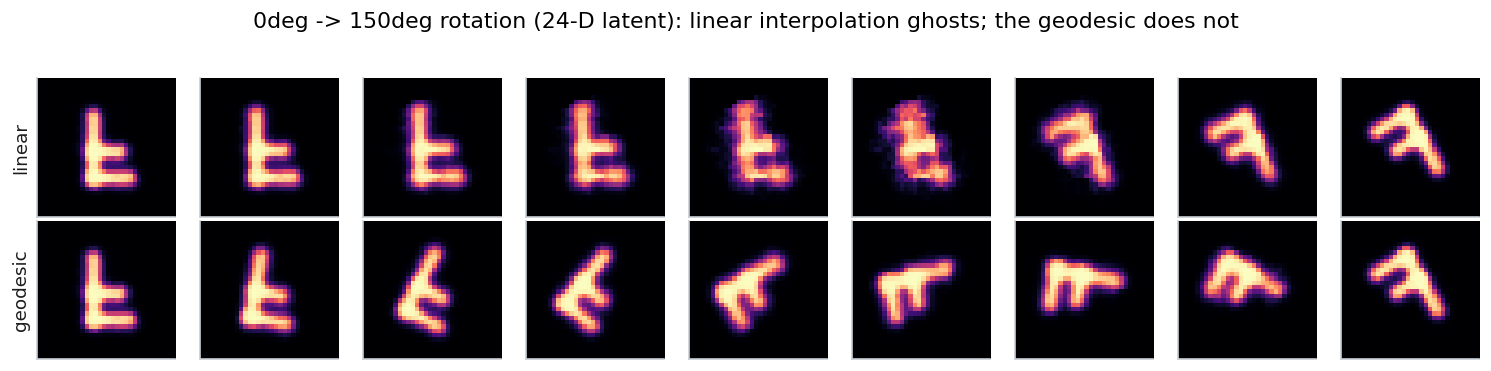

In [7]:
# Arc-length reparametrise for a constant-speed strip, then compare the two paths.
geo_disp = np.asarray(reparametrize_arclength(jnp.asarray(geodesic), n_steps))
show_strip([linear, geo_disp], ["linear", "geodesic"],
           "0deg -> 150deg rotation (24-D latent): linear interpolation ghosts; the geodesic does not")

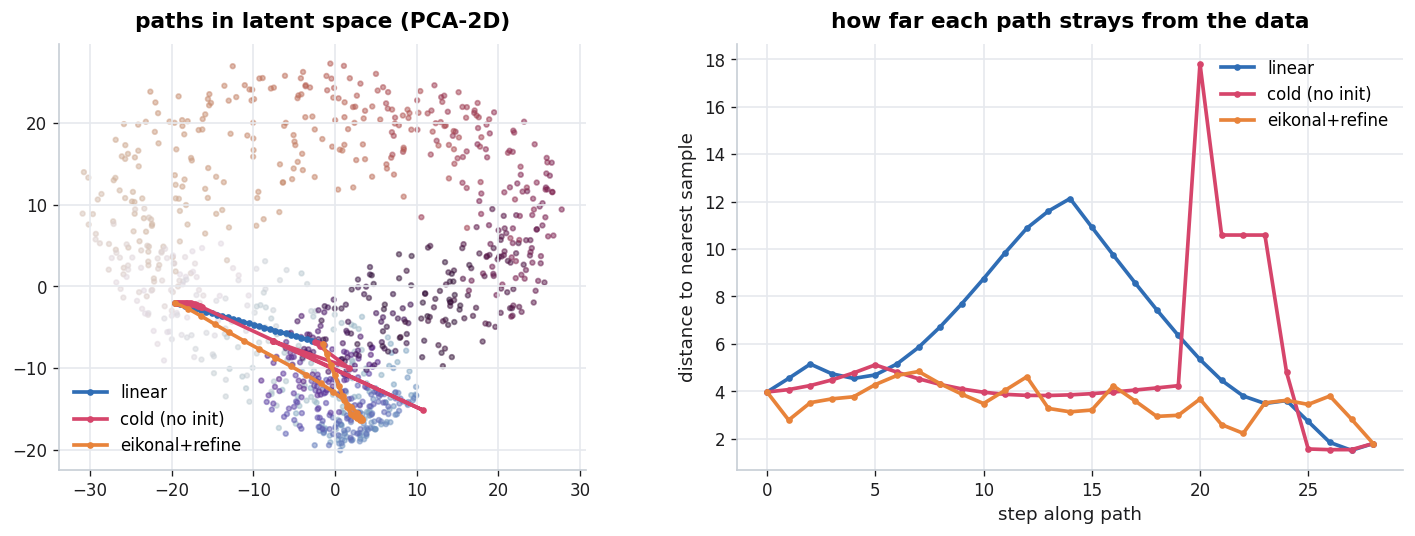

In [8]:
# The paths against the latent loop (PCA-2D); the cold path tunnels through the void.
def to2d(P): return (np.asarray(P) - Z.mean(0)) @ Vt[:2].T
lin2, geo2, cold2 = to2d(linear), to2d(geo_disp), to2d(cold.xs)

fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.6))
ax[0].scatter(Z2[:, 0], Z2[:, 1], s=8, c=np.degrees(ang_label), cmap="twilight", alpha=0.5)
ax[0].plot(lin2[:, 0], lin2[:, 1], "-o", ms=3, color=PALETTE["primary"], label="linear")
ax[0].plot(cold2[:, 0], cold2[:, 1], "-o", ms=3, color=PALETTE["rose"], label="cold (no init)")
ax[0].plot(geo2[:, 0], geo2[:, 1], "-o", ms=3, color=PALETTE["accent"], label="eikonal+refine")
ax[0].set_aspect("equal"); ax[0].set_title("paths in latent space (PCA-2D)"); ax[0].legend()
ax[1].plot(nn_dist(linear), "-o", ms=3, color=PALETTE["primary"], label="linear")
ax[1].plot(nn_dist(cold.xs), "-o", ms=3, color=PALETTE["rose"], label="cold (no init)")
ax[1].plot(nn_dist(geo_disp), "-o", ms=3, color=PALETTE["accent"], label="eikonal+refine")
ax[1].set_xlabel("step along path"); ax[1].set_ylabel("distance to nearest sample")
ax[1].set_title("how far each path strays from the data"); ax[1].legend()
plt.tight_layout(); plt.show()

## 5. Vertex distribution along the path

Discrete geodesics commonly exhibit **vertex bunching** — clusters of short segments
beside a sparse stretch — which limits how well a fixed vertex budget resolves the
energy valley. The effect has two distinct sources, both benign:

1. **Incorrect basin (tunnelling).** The cold path concentrates most of its length in
   a single segment that leaps across the void; its high segment-length coefficient
   of variation (CV) is a direct fingerprint of the tunnelling addressed in Section 4.
2. **Constant-Finsler-speed parametrisation.** Even the correct geodesic is unevenly
   sampled: energy minimisation drives $\sqrt{g}\,\lVert\dot\gamma\rVert$ to a constant,
   so vertices are naturally sparser where the metric is cheap (on the data) and denser
   where it is expensive. This affects the *sampling*, not the path image.

`reparametrize_arclength` redistributes vertices to uniform arc length (CV $\to 0$)
for display and downstream sampling without altering the curve. Bunching is therefore
not evidence of an incorrect geodesic; the cold path's *excess* bunching is.

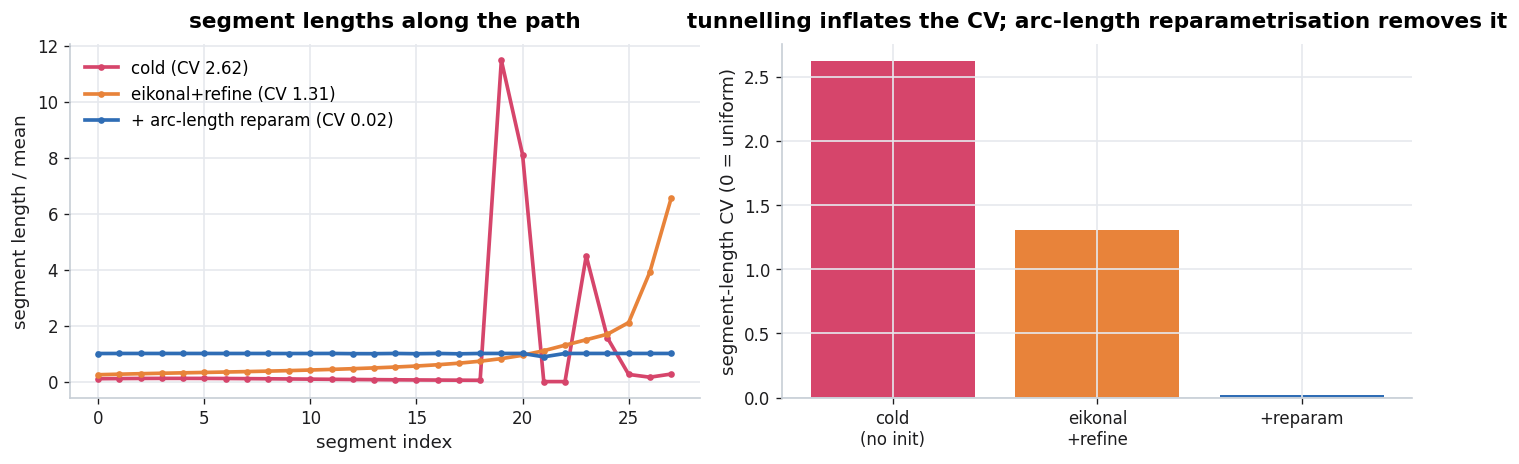

seg-length CV:  cold 2.62  ->  eikonal+refine 1.31  ->  +reparam 0.02


In [9]:
def seg_cv(P):
    s = np.linalg.norm(np.diff(np.asarray(P), axis=0), axis=1)
    return s.std() / s.mean(), s

cv_cold, s_cold = seg_cv(cold.xs)
cv_warm, s_warm = seg_cv(geodesic)
cv_rep, s_rep = seg_cv(geo_disp)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(s_cold / s_cold.mean(), "-o", ms=3, color=PALETTE["rose"], label=f"cold (CV {cv_cold:.2f})")
ax[0].plot(s_warm / s_warm.mean(), "-o", ms=3, color=PALETTE["accent"], label=f"eikonal+refine (CV {cv_warm:.2f})")
ax[0].plot(s_rep / s_rep.mean(), "-o", ms=3, color=PALETTE["primary"], label=f"+ arc-length reparam (CV {cv_rep:.2f})")
ax[0].set_xlabel("segment index"); ax[0].set_ylabel("segment length / mean")
ax[0].set_title("segment lengths along the path"); ax[0].legend()
ax[1].bar(["cold\n(no init)", "eikonal\n+refine", "+reparam"], [cv_cold, cv_warm, cv_rep],
          color=[PALETTE["rose"], PALETTE["accent"], PALETTE["primary"]])
ax[1].set_ylabel("segment-length CV (0 = uniform)")
ax[1].set_title("tunnelling inflates the CV; arc-length reparametrisation removes it")
plt.tight_layout(); plt.show()
print(f"seg-length CV:  cold {cv_cold:.2f}  ->  eikonal+refine {cv_warm:.2f}  ->  +reparam {cv_rep:.2f}")

## 6. When the boundary-value problem is hard: a controlled study

To explain *why* the global initialisation is necessary, we isolate the difficulty
from the learned metric using an **analytic ring-confinement metric** whose exact
geodesic between two ring points is the connecting arc, in any dimension $D$:
$$ G(z)=\exp\!\big(\alpha\,c(z)\big)I,\quad c(z)=\big((r-R)^2+\lVert z_\perp\rVert^2\big)/w^2,\quad r=\sqrt{z_0^2+z_1^2}.$$

In [10]:
R = 1.0

def ring_metric(D, alpha, w):
    def g_net(z):
        r = jnp.sqrt(z[0] ** 2 + z[1] ** 2 + 1e-12)
        c = ((r - R) ** 2 + jnp.sum(z[2:] ** 2)) / (w ** 2)
        return jnp.exp(alpha * c) * jnp.eye(D)
    return Riemannian(EuclideanSpace(D), g_net)

def ring_pt(theta, D):
    z = np.zeros(D, np.float32); z[0], z[1] = R*np.cos(theta), R*np.sin(theta)
    return jnp.asarray(z)

from ham.geometry import Euclidean

# --- Finding 1: O(N^2) critical slowing. Relax a low-frequency bump on a Euclidean
# path -- pure heat diffusion on the 1-D path Laplacian.
def relax_bump(Nv, iters):
    t = np.linspace(0, 1, Nv + 1)
    bump = np.stack([t, 0.3 * np.sin(np.pi * t)], 1).astype(np.float32)
    m = Euclidean(EuclideanSpace(2))
    s = AVBDSolver(step_size=0.2, iterations=iters, grad_clip=1e9)
    tr = s.solve(m, jnp.array([0.,0.]), jnp.array([1.,0.]), n_steps=Nv,
                 key=jax.random.PRNGKey(0), init_path=jnp.asarray(bump))
    return float(np.max(np.abs(np.asarray(tr.xs)[:, 1])))

Ns, taus = [8, 16, 32, 64], []
for Nv in Ns:
    tau = next(b for b in [2,4,8,16,32,64,128,256,512,1024,2048,4096,8192,16384]
               if relax_bump(Nv, b) < 0.05 * 0.3)
    taus.append(tau)
slope = np.polyfit(np.log(Ns), np.log(taus), 1)[0]
print("Finding 1 - critical slowing down (sweeps to relax a global bump):")
for Nv, tau in zip(Ns, taus): print(f"   N={Nv:3d}  tau={tau:5d}")
print(f"   power law  tau ~ N^{slope:.2f}   (2.0 = 1-D Laplacian / Gauss-Seidel)")

Finding 1 - critical slowing down (sweeps to relax a global bump):
   N=  8  tau=  128
   N= 16  tau=  512
   N= 32  tau= 2048
   N= 64  tau= 8192
   power law  tau ~ N^2.00   (2.0 = 1-D Laplacian / Gauss-Seidel)


In [11]:
# --- Finding 2: dimension is NOT the bottleneck. Same arc, same N, vary D.
def arc_rmse(xs, t0, t1, D):
    xs = np.asarray(xs); n = xs.shape[0]-1; ts = np.linspace(t0, t1, n+1)
    arc = np.zeros((n+1, D), np.float32); arc[:,0], arc[:,1] = R*np.cos(ts), R*np.sin(ts)
    return float(np.sqrt(np.mean(np.sum((xs-arc)**2, axis=1))))

th = np.deg2rad(120)
print("Finding 2 - convergence is independent of ambient dimension D:")
for D in [2, 16, 64, 256]:
    s = AVBDSolver(step_size=0.05, iterations=600, grad_clip=10.0)
    tr = s.solve(ring_metric(D, 4.0, 0.35), ring_pt(0,D), ring_pt(th,D),
                 n_steps=24, key=jax.random.PRNGKey(0))
    print(f"   D={D:4d}  path-arc RMSE @600 sweeps = {arc_rmse(tr.xs,0,th,D):.4f}")

# --- Finding 3: stiff cold starts diverge / tunnel. Brute force at high alpha blows up.
print("\nFinding 3 - cold brute force diverges in stiff voids (arc=150, D=64):")
for alpha in [3.0, 6.0, 9.0]:
    s = AVBDSolver(step_size=0.05, iterations=2000, grad_clip=10.0)
    tr = s.solve(ring_metric(64, alpha, 0.30), ring_pt(0,64), ring_pt(np.deg2rad(150),64),
                 n_steps=32, key=jax.random.PRNGKey(0))
    print(f"   alpha={alpha:4.0f}  final energy = {float(tr.energy):.2e}")

Finding 2 - convergence is independent of ambient dimension D:


   D=   2  path-arc RMSE @600 sweeps = 0.0268


   D=  16  path-arc RMSE @600 sweeps = 0.0266


   D=  64  path-arc RMSE @600 sweeps = 0.0267


   D= 256  path-arc RMSE @600 sweeps = 0.0267

Finding 3 - cold brute force diverges in stiff voids (arc=150, D=64):


   alpha=   3  final energy = 1.04e-01


   alpha=   6  final energy = 1.33e+32


   alpha=   9  final energy = 1.62e+35


**Interpretation.**

* **The difficulty is not dimensional** (Finding 2 is flat): the block-tridiagonal
  adjoint and the per-vertex update are dimension-agnostic. The governing factors are
  *path length* $N$, *metric stiffness* $\alpha$, and the *global topology* (the
  homotopy class).
* **$O(N^2)$ critical slowing** (Finding 1): a Gauss-Seidel sweep moves information
  ~one vertex, so a global low-frequency deformation needs $\sim N^2$ sweeps.
* **Stiff divergence / tunnelling** (Finding 3): a fixed-step gradient update is
  unstable in the $\exp(\alpha c)$ void, and because the discrete energy samples the
  metric at the segment *start*, a long segment can leap across a void it never
  pays for — the midpoint quadrature of `SegmentQuadratureMetric` (§3) closes that
  loophole, but only the **global init** fixes the homotopy class.

## 7. Path-length-independent convergence with `GaussNewtonGeodesic`

Within the convergence basin, the *global* second-order step converges in a number
of iterations **independent of $N$**, whereas local Gauss–Seidel relaxation incurs
the $O(N^2)$ critical slowing of Finding 1. We verify this on the ring metric,
warm-starting both solvers near the arc so as to compare convergence *rates* rather
than globalisation.

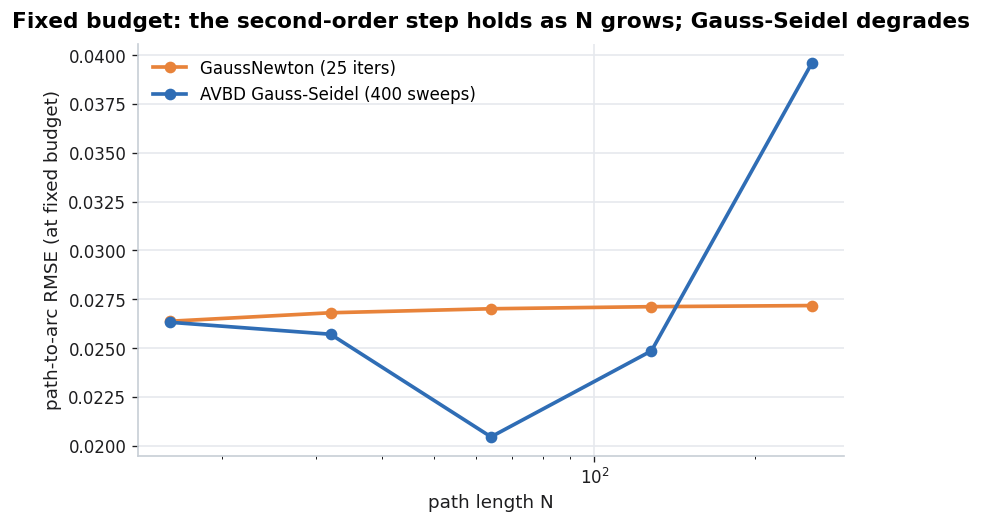

N        : [16, 32, 64, 128, 256]
GN  RMSE : ['0.026', '0.027', '0.027', '0.027', '0.027'] (flat -> N-independent, 25 iters)
GS  RMSE : ['0.026', '0.026', '0.020', '0.025', '0.040'] (rises with N -> O(N^2) at 400 sweeps)


In [12]:
th = np.deg2rad(120)
Ns = [16, 32, 64, 128, 256]
GN_ITERS, GS_SWEEPS = 25, 400
gn_rmse, gs_rmse = [], []
for Nv in Ns:
    m = ring_metric(64, 4.0, 0.35)
    ts = np.linspace(0, th, Nv + 1)
    warm = np.zeros((Nv + 1, 64), np.float32)
    warm[:, 0], warm[:, 1] = R*np.cos(ts), R*np.sin(ts)
    warm += np.random.RandomState(0).randn(Nv + 1, 64).astype(np.float32) * 0.03
    warm = jnp.asarray(warm)
    g = GaussNewtonGeodesic(iterations=GN_ITERS, mu0=1e-3).solve(
        m, ring_pt(0,64), ring_pt(th,64), n_steps=Nv, init_path=warm)
    s = AVBDSolver(step_size=0.05, iterations=GS_SWEEPS, grad_clip=10.0).solve(
        m, ring_pt(0,64), ring_pt(th,64), n_steps=Nv, init_path=warm, key=jax.random.PRNGKey(0))
    gn_rmse.append(arc_rmse(g.xs, 0, th, 64))
    gs_rmse.append(arc_rmse(s.xs, 0, th, 64))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.semilogx(Ns, gn_rmse, "-o", color=PALETTE["accent"], label=f"GaussNewton ({GN_ITERS} iters)")
ax.semilogx(Ns, gs_rmse, "-o", color=PALETTE["primary"], label=f"AVBD Gauss-Seidel ({GS_SWEEPS} sweeps)")
ax.set_xlabel("path length N"); ax.set_ylabel("path-to-arc RMSE (at fixed budget)")
ax.set_title("Fixed budget: the second-order step holds as N grows; Gauss-Seidel degrades")
ax.legend(); plt.tight_layout(); plt.show()
print("N        :", Ns)
print("GN  RMSE :", [f"{r:.3f}" for r in gn_rmse], f"(flat -> N-independent, {GN_ITERS} iters)")
print("GS  RMSE :", [f"{r:.3f}" for r in gs_rmse], f"(rises with N -> O(N^2) at {GS_SWEEPS} sweeps)")

## 8. Limitations and challenges

* **Global non-convexity.** The geodesic boundary-value problem is globally
  non-convex, so any local solver (Gauss–Seidel or Newton) requires an initial path
  in the correct basin; from a straight line into a stiff void it stalls, diverges,
  or tunnels. This is intrinsic to the problem rather than specific to HAM — the
  established remedies are numerical continuation, a graph/eikonal initialisation, or
  a learned initialiser.
* **Two-stage architecture.** Accordingly, the reliable approach is a global
  initialiser (topology) composed with a local refiner — `AVBDSolver` /
  `GaussNewtonGeodesic` — that produces the smooth, off-sample, differentiable,
  transport-capable geodesic. The global stage adds a small overhead (≈6% here); the
  local stage supplies the geometric accuracy a shortest-path graph cannot.
* **Cost of the second-order step.** `GaussNewtonGeodesic` forms $D\times D$ Hessian
  blocks at $O(N D^3)$ per iteration. It is preferable at large $N$ or high precision
  on Euclidean-ambient latents; for inexpensive sweeps or strongly curved intrinsic
  manifolds, `AVBDSolver` remains the better default.
* **Relation to prior work.** [Syrota et al. (2025)](https://arxiv.org/abs/2505.18230)
  adopt the same conformal-metric family but learn a low-parameter neural interpolant
  per metric, whose smoothness prior sidesteps globalisation by construction at the
  cost of a trained network. HAM instead solves the full BVP for any metric without
  per-pair training, with the global initialisation stage playing the role of that
  prior.
* **Scope.** A full MNIST/AFHQ latent, and a Finsler–Randers drift that encodes the
  manifold's tangent flow directly in the metric (yielding *directed* geodesics for
  navigation and robotics), are natural extensions left to dedicated experiments.

To apply the notebook to a trained model, replace `render_letter` / `X` with a
decoder and its encoded dataset; the metric, initialiser, and solvers are unchanged.